In [1]:
import json
import networkx as nx
# import matplotlib as plt

In [2]:
with open('./saved_tracks/c.json') as file:
    system = json.load(file)

In [3]:
G = nx.Graph()
nodes = {}
edges: list = []
pos = {}

In [4]:
for segment_id, segment in system["segments"].items():
    segment_type = segment["type"]
    ports = segment["connections"]

    for port, target in ports.items():
        own_port = f"{segment_id}.{port}"
        other_port = target

        print(own_port,other_port)
        if not target:
            node_id = f"{own_port}_end"
        elif(
            own_port.split(".")[0] <
            other_port.split(".")[0]
        ):
            node_id = f"{own_port}_{other_port}"
        else:
            node_id = f"{other_port}_{own_port}"

        if node_id not in nodes:
            nodes[node_id] = node_id
            print(segment)
            pos[node_id] = segment["location"][port]

        ports[port] = node_id

    # print(ports)

    if segment_type in ("st", "cl", "cr"):
        tuple = (ports["a"], ports["b"])
        # print(tuple)
        edges.append((ports["a"], ports["b"]))
    elif segment_type in ("sl", "sr"):
        edges.append((ports["a"], ports["b"]))
        if "c" in ports and ports["c"] is not None:
            edges.append((ports["a"], ports["c"]))
    else:
        print("segment type not found")

4ef2e5d2-a31d-4e20-9be3-a4419adbed22.a None
{'type': 'st', 'connections': {'a': None, 'b': 'ee03c4cb-11fd-4a9d-ab4f-ff59bef7fc75.a'}, 'location': {'a': [0.0, -0.0], 'b': [200.0, 0.0]}, 'metadata': {'starting_end': 'a', 'length_a.b': 200, 'coords': [0, 0, 90]}}
4ef2e5d2-a31d-4e20-9be3-a4419adbed22.b ee03c4cb-11fd-4a9d-ab4f-ff59bef7fc75.a
{'type': 'st', 'connections': {'a': '4ef2e5d2-a31d-4e20-9be3-a4419adbed22.a_end', 'b': 'ee03c4cb-11fd-4a9d-ab4f-ff59bef7fc75.a'}, 'location': {'a': [0.0, -0.0], 'b': [200.0, 0.0]}, 'metadata': {'starting_end': 'a', 'length_a.b': 200, 'coords': [0, 0, 90]}}
ee03c4cb-11fd-4a9d-ab4f-ff59bef7fc75.a 4ef2e5d2-a31d-4e20-9be3-a4419adbed22.b
ee03c4cb-11fd-4a9d-ab4f-ff59bef7fc75.b df4c89ff-4630-44ff-a10a-569af4c2920c.a
{'type': 'cl', 'connections': {'a': '4ef2e5d2-a31d-4e20-9be3-a4419adbed22.b_ee03c4cb-11fd-4a9d-ab4f-ff59bef7fc75.a', 'b': 'df4c89ff-4630-44ff-a10a-569af4c2920c.a'}, 'location': {'a': [200.0, -0.0], 'b': [400.0, 53.59]}, 'metadata': {'starting_end':

In [5]:
len(nodes)

9

In [6]:
len(pos)

9

In [7]:
pos

{'4ef2e5d2-a31d-4e20-9be3-a4419adbed22.a_end': [0.0, -0.0],
 '4ef2e5d2-a31d-4e20-9be3-a4419adbed22.b_ee03c4cb-11fd-4a9d-ab4f-ff59bef7fc75.a': [200.0,
  0.0],
 'df4c89ff-4630-44ff-a10a-569af4c2920c.a_ee03c4cb-11fd-4a9d-ab4f-ff59bef7fc75.b': [400.0,
  53.59],
 'df4c89ff-4630-44ff-a10a-569af4c2920c.b_eb3c4d5f-a9de-47c6-bee2-d3c7b7ff6107.a': [546.41,
  200.0],
 'e37f9c19-3674-4b98-8f16-6a774d58612e.a_eb3c4d5f-a9de-47c6-bee2-d3c7b7ff6107.b': [600.0,
  400.0],
 'acb2b05c-a6cb-4ad6-b453-d225adb52112.a_e37f9c19-3674-4b98-8f16-6a774d58612e.b': [546.41,
  600.0],
 'acb2b05c-a6cb-4ad6-b453-d225adb52112.b_b5b61499-7e9a-470a-91e4-a28fc9eaa826.a': [400.0,
  746.41],
 '34bf691a-45a3-4392-a8e3-186457d4fcb5.a_b5b61499-7e9a-470a-91e4-a28fc9eaa826.b': [200.0,
  800.0],
 '34bf691a-45a3-4392-a8e3-186457d4fcb5.b_end': [0.0, 800.0]}

In [8]:
G.add_edges_from(edges)

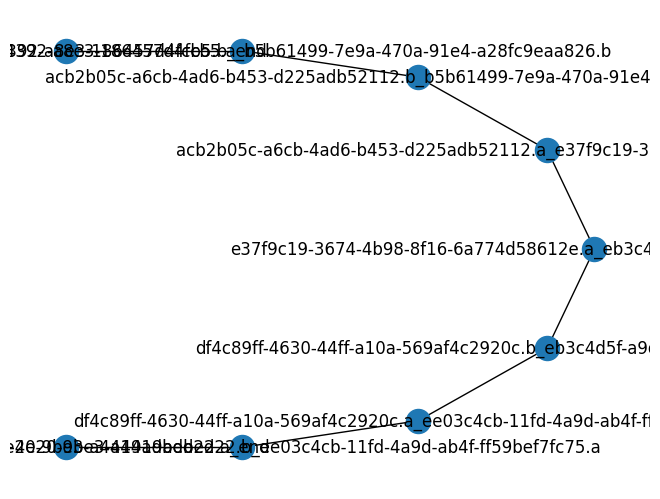

In [9]:
# pos = nx.spring_layout(G)

# for key, coords  in pos.items():
#     pos[key] = coords[::-1]


nx.draw(G, pos, with_labels=True)
# print(pos, pos2)


In [10]:
path = nx.shortest_path(G, source="3.b_4.b", target="20.a_end")

NodeNotFound: Source 3.b_4.b is not in G

In [ ]:
path